In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.statespace.tools import diff

In [2]:
mnmonthlytemps1 = pd.read_csv("manhattan_heats_monthly.csv", parse_dates=['Date'], index_col=0)
mnmonthlytemps1.shape
mnmonthlytemps1.head(30)

,ntaname,cdtaname,shape_leng,boroname,ntatype,nta2020,borocode,countyfips,ntaabbrev,cdta2020,Date,Value
shape_area,,,,,,,,,,,,
15797449.56,Upper West Side-Lincoln Square,MN07 Upper West Side (CD 7 Approximation),19952.42063,Manhattan,0,MN0701,1,61,UWS_LclnSq,MN07,2008-01-01,31.424
15797449.56,Upper West Side-Lincoln Square,MN07 Upper West Side (CD 7 Approximation),19952.42063,Manhattan,0,MN0701,1,61,UWS_LclnSq,MN07,2008-02-01,31.202
15797449.56,Upper West Side-Lincoln Square,MN07 Upper West Side (CD 7 Approximation),19952.42063,Manhattan,0,MN0701,1,61,UWS_LclnSq,MN07,2008-03-01,51.830
15797449.56,Upper West Side-Lincoln Square,MN07 Upper West Side (CD 7 Approximation),19952.42063,Manhattan,0,MN0701,1,61,UWS_LclnSq,MN07,2008-04-01,68.792
15797449.56,Upper West Side-Lincoln Square,MN07 Upper West Side (CD 7 Approximation),19952.42063,Manhattan,0,MN0701,1,61,UWS_LclnSq,MN07,2008-05-01,75.722
15797449.56,Upper West Side-Lincoln Square,MN07 Upper West Side (CD 7 Approximation),19952.42063,Manhattan,0,MN0701,1,61,UWS_LclnSq,MN07,2008-06-01,86.738
15797449.56,Upper West Side-Lincoln Square,MN07 Upper West Side (CD 7 Approximation),19952.42063,Manhattan,0,MN0701,1,61,UWS_LclnSq,MN07,2008-07-01,89.015
15797449.56,Upper West Side-Lincoln Square,MN07 Upper West Side (CD 7 Approximation),19952.42063,Manhattan,0,MN0701,1,61,UWS_LclnSq,MN07,2008-08-01,85.586
15797449.56,Upper West Side-Lincoln Square,MN07 Upper West Side (CD 7 Approximation),19952.42063,Manhattan,0,MN0701,1,61,UWS_LclnSq,MN07,2008-09-01,73.418


In [3]:
mnmonthlytemps = mnmonthlytemps1.groupby('Date')['Value'].mean()

print(mnmonthlytemps.shape)
print(mnmonthlytemps.head())

(144,)
Date
2008-01-01    32.835956
2008-02-01    35.584961
2008-03-01    50.659371
2008-04-01    70.701534
2008-05-01    75.529214
Name: Value, dtype: float64


In [4]:
print(mnmonthlytemps.head(15))  # See what months you actually have in 2008
print(mnmonthlytemps.shape)
print(mnmonthlytemps.isna().sum())

Date
2008-01-01    32.835956
2008-02-01    35.584961
2008-03-01    50.659371
2008-04-01    70.701534
2008-05-01    75.529214
2008-06-01    87.209982
2008-07-01    89.858714
2008-08-01    86.052487
2008-09-01    74.158559
2008-10-01    60.283892
2008-11-01    46.265606
2008-12-01    39.877034
2009-01-01    30.307183
2009-02-01    41.113940
2009-03-01    55.839624
Name: Value, dtype: float64
(144,)
0


In [5]:
result = adfuller(mnmonthlytemps, autolag='AIC')
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
print(f'lags: {result[2]}')
print(f'observations: {result[3]}')
for key, value in result[4].items():
    print('Critial Values:')
    print(f'   {key}, {value}')

ADF Statistic: -2.7780385122461295
p-value: 0.061479933043050224
lags: 14
observations: 129
Critial Values:
   1%, -3.482087964046026
Critial Values:
   5%, -2.8842185101614626
Critial Values:
   10%, -2.578864381347275


In [6]:
seasonal_diff = mnmonthlytemps.diff(12).dropna()
result = adfuller(seasonal_diff, autolag='AIC')
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

ADF Statistic: -2.560093509893033
p-value: 0.10152876526294263


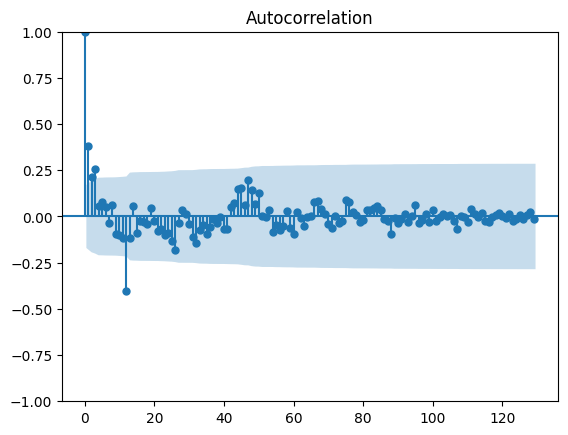

<Figure size 1000x400 with 0 Axes>

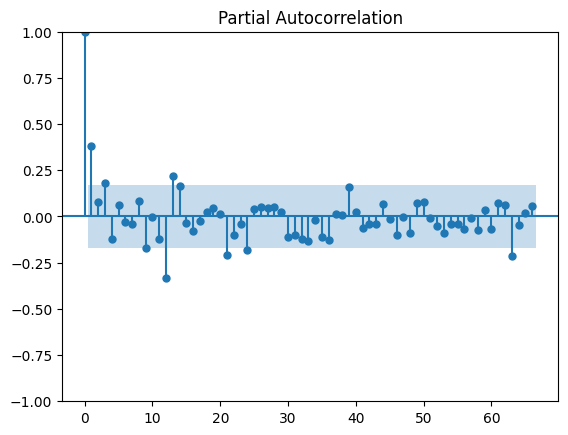

In [7]:
plot_acf(mnmonthlytemps.diff(12).dropna(), lags=129)
plt.show()

plt.figure(figsize=(10, 4))
plot_pacf(mnmonthlytemps.diff(12).dropna(), lags=66)
plt.show()

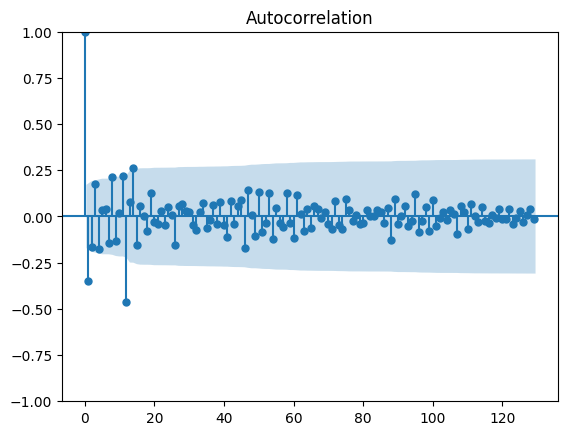

<Figure size 1000x400 with 0 Axes>

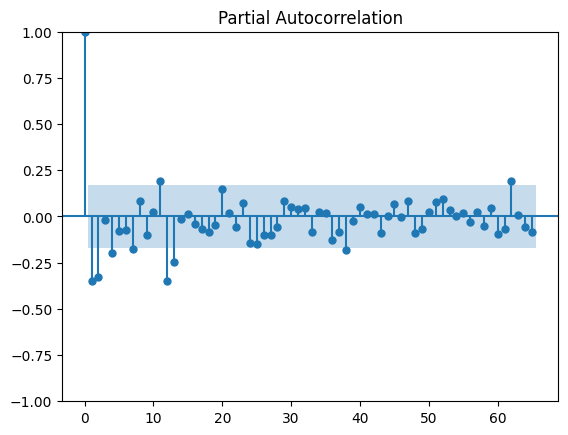

In [8]:
plot_acf(mnmonthlytemps.diff(12).diff(1).dropna(), lags=129)
plt.show()

plt.figure(figsize=(10, 4))
plot_pacf(mnmonthlytemps.diff(12).diff(1).dropna(), lags=65)
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


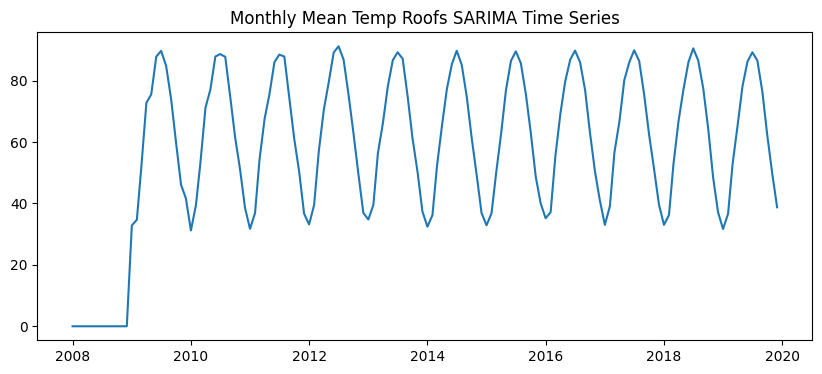

                                     SARIMAX Results                                      
Dep. Variable:                              Value   No. Observations:                  144
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -342.640
Date:                            Thu, 30 Apr 2026   AIC                            695.279
Time:                                    20:00:46   BIC                            709.693
Sample:                                01-01-2008   HQIC                           701.136
                                     - 12-01-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6756      0.177      3.812      0.000       0.328       1.023
ma.L1         -0.3708      0.216   

In [9]:
p, d, q = 1, 0, 1
P, D, Q, s = 1, 1, 1, 12

model1 = SARIMAX(mnmonthlytemps, order=(p, d, q), seasonal_order=(P, D, Q, s))
model1_fit = model1.fit()
plt.figure(figsize=(10, 4))
plt.plot(model1_fit.fittedvalues)
plt.title("Monthly Mean Temp Roofs SARIMA Time Series")
plt.show()

print(model1_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


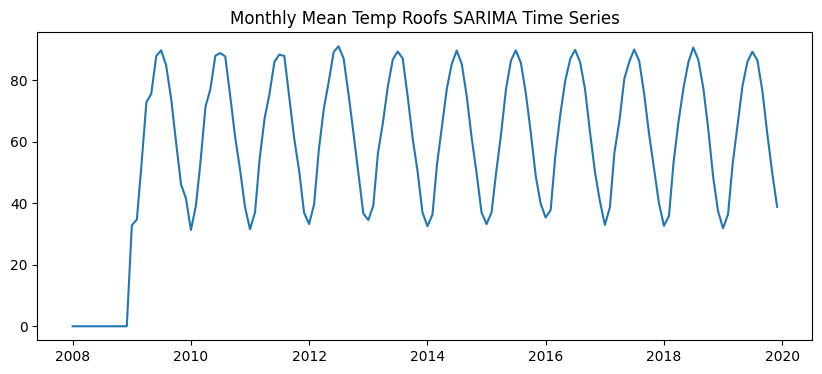

                                     SARIMAX Results                                      
Dep. Variable:                              Value   No. Observations:                  144
Model:             SARIMAX(1, 0, 1)x(0, 1, 1, 12)   Log Likelihood                -342.873
Date:                            Thu, 30 Apr 2026   AIC                            693.747
Time:                                    20:00:47   BIC                            705.278
Sample:                                01-01-2008   HQIC                           698.432
                                     - 12-01-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6830      0.175      3.897      0.000       0.340       1.026
ma.L1         -0.3763      0.215   

In [10]:
#best AIC model
p, d, q = 1, 0, 1
P, D, Q, s = 0, 1, 1, 12

model2 = SARIMAX(mnmonthlytemps, order=(p, d, q), seasonal_order=(P, D, Q, s))
model2_fit = model2.fit()
plt.figure(figsize=(10, 4))
plt.plot(model2_fit.fittedvalues)
plt.title("Monthly Mean Temp Roofs SARIMA Time Series")
plt.show()

print(model2_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


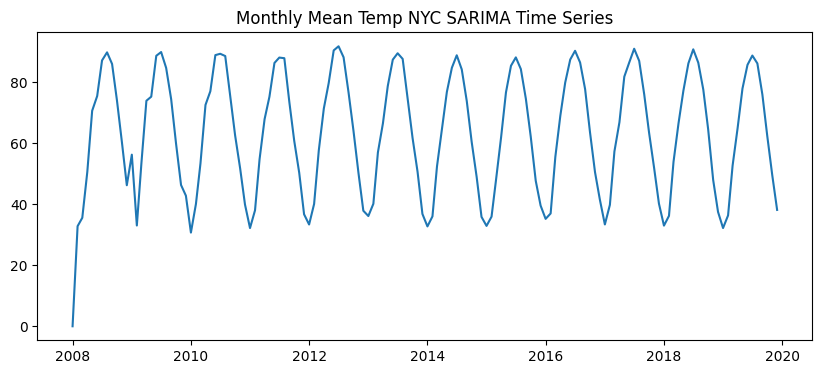

                                     SARIMAX Results                                      
Dep. Variable:                              Value   No. Observations:                  144
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -345.270
Date:                            Thu, 30 Apr 2026   AIC                            698.540
Time:                                    20:00:48   BIC                            710.041
Sample:                                01-01-2008   HQIC                           703.213
                                     - 12-01-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2862      0.115      2.481      0.013       0.060       0.512
ma.L1         -0.8947      0.066   

In [11]:
#final model due to JB, negligible difference in AIC compared to statistical justification
p, d, q = 1, 1, 1
P, D, Q, s = 0, 1, 1, 12

model3 = SARIMAX(mnmonthlytemps, order=(p, d, q), seasonal_order=(P, D, Q, s))
model3_fit = model3.fit()
plt.figure(figsize=(10, 4))
plt.plot(model3_fit.fittedvalues)
plt.title("Monthly Mean Temp NYC SARIMA Time Series")
plt.show()

print(model3_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


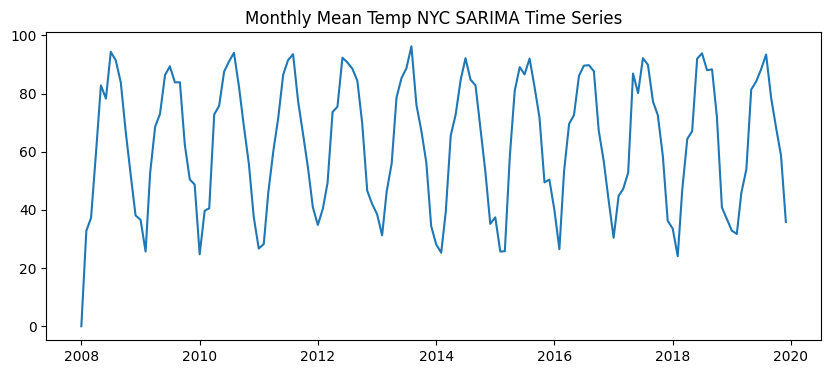

                                     SARIMAX Results                                      
Dep. Variable:                              Value   No. Observations:                  144
Model:             SARIMAX(1, 1, 1)x(0, 0, 1, 12)   Log Likelihood                -476.146
Date:                            Thu, 30 Apr 2026   AIC                            960.292
Time:                                    20:00:48   BIC                            972.143
Sample:                                01-01-2008   HQIC                           965.108
                                     - 12-01-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5946      0.143      4.169      0.000       0.315       0.874
ma.L1          0.0191      0.177   

In [12]:
p, d, q = 1, 1, 1
P, D, Q, s = 0, 0, 1, 12

model4 = SARIMAX(mnmonthlytemps, order=(p, d, q), seasonal_order=(P, D, Q, s))
model4_fit = model4.fit()
plt.figure(figsize=(10, 4))
plt.plot(model4_fit.fittedvalues)
plt.title("Monthly Mean Temp NYC SARIMA Time Series")
plt.show()

print(model4_fit.summary())

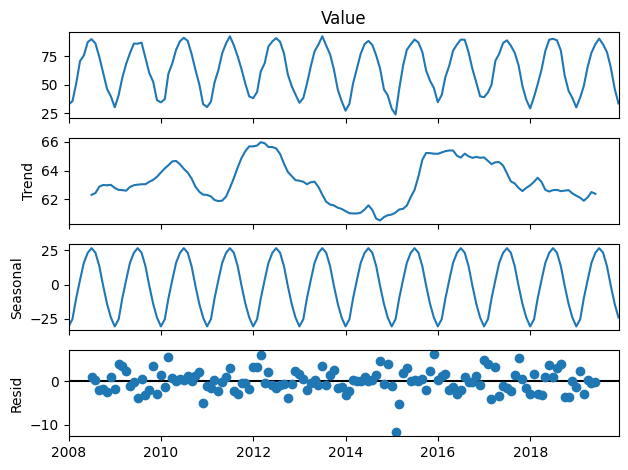

In [13]:
decomp = seasonal_decompose(mnmonthlytemps, model='additive', period=12)

# Access components
trend = decomp.trend
seasonal = decomp.seasonal
residual = decomp.resid

# Visualize
decomp.plot()
plt.show()

In [14]:
mnbright = pd.read_excel("nynta2020_manhattan.xlsx")
mnbright.shape
mnbright.head()

,OBJECTID,BoroCode,BoroName,CountyFIPS,NTA2020,NTAName,NTAAbbrev,NTAType,CDTA2020,CDTAName,Shape_Leng,NTAName_1,mean_brightness,median_brightness,total_buildings,dark_roof_count,pct_dark_roofs,Shape_Length,Shape_Area
0,17.0,1.0,Manhattan,61.0,MN0661,United Nations,UN,6.0,MN06,MN06 East Midtown-Murray Hill (CD 6 Approximat...,5307.391106,United Nations,112.858715,112.858715,1.0,0.0,0.0,5307.391662,1.091250e+06
1,27.0,1.0,Manhattan,61.0,MN1001,Harlem (South),Hrlm_S,0.0,MN10,MN10 Harlem (CD 10 Equivalent),16663.339342,Harlem (South),133.028106,136.324420,1824.0,295.0,16.2,16663.284917,1.442641e+07
2,28.0,1.0,Manhattan,61.0,MN1002,Harlem (North),Hrlm_N,0.0,MN10,MN10 Harlem (CD 10 Equivalent),30930.714854,Harlem (North),131.486013,134.636158,2214.0,388.0,17.5,26079.304033,2.379291e+07
3,33.0,1.0,Manhattan,61.0,MN1203,Inwood,Inwd,0.0,MN12,MN12 Washington Heights-Inwood (CD 12 Equivalent),23742.696351,Inwood,132.068491,139.172461,480.0,85.0,17.7,23347.840656,1.443688e+07
4,8.0,1.0,Manhattan,61.0,MN0303,East Village,EstVlg,0.0,MN03,MN03 Lower East Side-Chinatown (CD 3 Equivalent),22376.995883,East Village,127.738665,129.302383,2124.0,378.0,17.8,21976.654622,1.898222e+07


In [15]:
# Define the bins and labels
bins = [0, 30.18, 100]
labels = [0, 1]

# Create a new classification column
mnbright['roof_class'] = pd.cut(mnbright['pct_dark_roofs'], bins=bins, labels=labels, include_lowest=True)

# Group by NTA2020 and roof class
grouped = mnbright.groupby(['NTA2020', 'roof_class']).size().reset_index(name='count')

print(grouped)

   NTA2020 roof_class  count
0   MN0101          0      0
1   MN0101          1      1
2   MN0102          0      0
3   MN0102          1      1
4   MN0201          0      1
..     ...        ...    ...
61  MN1201          1      0
62  MN1202          0      1
63  MN1202          1      0
64  MN1203          0      1
65  MN1203          1      0

[66 rows x 3 columns]


/tmp/ipykernel_12987/3952533957.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = mnbright.groupby(['NTA2020', 'roof_class']).size().reset_index(name='count')


In [16]:
print(mnbright[mnbright['pct_dark_roofs'] > 50])

    OBJECTID  BoroCode   BoroName  CountyFIPS NTA2020  \
29      11.0       1.0  Manhattan        61.0  MN0501   
30      16.0       1.0  Manhattan        61.0  MN0604   
31       1.0       1.0  Manhattan        61.0  MN0101   
32      12.0       1.0  Manhattan        61.0  MN0502   

                                 NTAName   NTAAbbrev  NTAType CDTA2020  \
29   Midtown South-Flatiron-Union Square    MdtwnSth      0.0     MN05   
30               East Midtown-Turtle Bay    EstMdtwn      0.0     MN06   
31  Financial District-Battery Park City        FiDi      0.0     MN01   
32                  Midtown-Times Square  Mdtwn_TmSq      0.0     MN05   

                                             CDTAName    Shape_Leng  \
29  MN05 Midtown-Flatiron-Union Square (CD 5 Appro...  18799.252087   
30  MN06 East Midtown-Murray Hill (CD 6 Approximat...  16656.141221   
31  MN01 Financial District-Tribeca (CD 1 Equivalent)  44672.486160   
32  MN05 Midtown-Flatiron-Union Square (CD 5 Appro...  2125

In [17]:
pivot = grouped.pivot(index='NTA2020', columns='roof_class', values='count').fillna(0)
print(pivot)

roof_class  0  1
NTA2020         
MN0101      0  1
MN0102      0  1
MN0201      1  0
MN0202      1  0
MN0203      1  0
MN0301      1  0
MN0302      1  0
MN0303      1  0
MN0401      0  1
MN0402      1  0
MN0501      0  1
MN0502      0  1
MN0601      0  1
MN0602      0  1
MN0603      0  1
MN0604      0  1
MN0661      1  0
MN0701      0  1
MN0702      0  1
MN0703      1  0
MN0801      0  1
MN0802      0  1
MN0803      0  1
MN0901      1  0
MN0902      1  0
MN0903      1  0
MN1001      1  0
MN1002      1  0
MN1101      1  0
MN1102      1  0
MN1201      1  0
MN1202      1  0
MN1203      1  0


In [18]:
mnbright.head()

,OBJECTID,BoroCode,BoroName,CountyFIPS,NTA2020,NTAName,NTAAbbrev,NTAType,CDTA2020,CDTAName,Shape_Leng,NTAName_1,mean_brightness,median_brightness,total_buildings,dark_roof_count,pct_dark_roofs,Shape_Length,Shape_Area,roof_class
0,17.0,1.0,Manhattan,61.0,MN0661,United Nations,UN,6.0,MN06,MN06 East Midtown-Murray Hill (CD 6 Approximat...,5307.391106,United Nations,112.858715,112.858715,1.0,0.0,0.0,5307.391662,1.091250e+06,0
1,27.0,1.0,Manhattan,61.0,MN1001,Harlem (South),Hrlm_S,0.0,MN10,MN10 Harlem (CD 10 Equivalent),16663.339342,Harlem (South),133.028106,136.324420,1824.0,295.0,16.2,16663.284917,1.442641e+07,0
2,28.0,1.0,Manhattan,61.0,MN1002,Harlem (North),Hrlm_N,0.0,MN10,MN10 Harlem (CD 10 Equivalent),30930.714854,Harlem (North),131.486013,134.636158,2214.0,388.0,17.5,26079.304033,2.379291e+07,0
3,33.0,1.0,Manhattan,61.0,MN1203,Inwood,Inwd,0.0,MN12,MN12 Washington Heights-Inwood (CD 12 Equivalent),23742.696351,Inwood,132.068491,139.172461,480.0,85.0,17.7,23347.840656,1.443688e+07,0
4,8.0,1.0,Manhattan,61.0,MN0303,East Village,EstVlg,0.0,MN03,MN03 Lower East Side-Chinatown (CD 3 Equivalent),22376.995883,East Village,127.738665,129.302383,2124.0,378.0,17.8,21976.654622,1.898222e+07,0


In [19]:
# Keep only NTA2020 and roof_class from mnbright
nta_class = mnbright[['NTA2020', 'pct_dark_roofs', 'roof_class']].drop_duplicates()

# Merge using left_on/right_on to handle different column names
mnmonthlytemps1 = mnmonthlytemps1.merge(nta_class, left_on='nta2020', right_on='NTA2020', how='left').drop(columns='NTA2020')


In [20]:
mnmonthlytemps1.head()

,ntaname,cdtaname,shape_leng,boroname,ntatype,nta2020,borocode,countyfips,ntaabbrev,cdta2020,Date,Value,pct_dark_roofs,roof_class
0,Upper West Side-Lincoln Square,MN07 Upper West Side (CD 7 Approximation),19952.42063,Manhattan,0,MN0701,1,61,UWS_LclnSq,MN07,2008-01-01,31.424,43.4,1
1,Upper West Side-Lincoln Square,MN07 Upper West Side (CD 7 Approximation),19952.42063,Manhattan,0,MN0701,1,61,UWS_LclnSq,MN07,2008-02-01,31.202,43.4,1
2,Upper West Side-Lincoln Square,MN07 Upper West Side (CD 7 Approximation),19952.42063,Manhattan,0,MN0701,1,61,UWS_LclnSq,MN07,2008-03-01,51.830,43.4,1
3,Upper West Side-Lincoln Square,MN07 Upper West Side (CD 7 Approximation),19952.42063,Manhattan,0,MN0701,1,61,UWS_LclnSq,MN07,2008-04-01,68.792,43.4,1
4,Upper West Side-Lincoln Square,MN07 Upper West Side (CD 7 Approximation),19952.42063,Manhattan,0,MN0701,1,61,UWS_LclnSq,MN07,2008-05-01,75.722,43.4,1


In [21]:
print(mnbright['roof_class'].value_counts())
display(mnbright.head())

roof_class
0    20
1    14
Name: count, dtype: int64


,OBJECTID,BoroCode,BoroName,CountyFIPS,NTA2020,NTAName,NTAAbbrev,NTAType,CDTA2020,CDTAName,Shape_Leng,NTAName_1,mean_brightness,median_brightness,total_buildings,dark_roof_count,pct_dark_roofs,Shape_Length,Shape_Area,roof_class
0,17.0,1.0,Manhattan,61.0,MN0661,United Nations,UN,6.0,MN06,MN06 East Midtown-Murray Hill (CD 6 Approximat...,5307.391106,United Nations,112.858715,112.858715,1.0,0.0,0.0,5307.391662,1.091250e+06,0
1,27.0,1.0,Manhattan,61.0,MN1001,Harlem (South),Hrlm_S,0.0,MN10,MN10 Harlem (CD 10 Equivalent),16663.339342,Harlem (South),133.028106,136.324420,1824.0,295.0,16.2,16663.284917,1.442641e+07,0
2,28.0,1.0,Manhattan,61.0,MN1002,Harlem (North),Hrlm_N,0.0,MN10,MN10 Harlem (CD 10 Equivalent),30930.714854,Harlem (North),131.486013,134.636158,2214.0,388.0,17.5,26079.304033,2.379291e+07,0
3,33.0,1.0,Manhattan,61.0,MN1203,Inwood,Inwd,0.0,MN12,MN12 Washington Heights-Inwood (CD 12 Equivalent),23742.696351,Inwood,132.068491,139.172461,480.0,85.0,17.7,23347.840656,1.443688e+07,0
4,8.0,1.0,Manhattan,61.0,MN0303,East Village,EstVlg,0.0,MN03,MN03 Lower East Side-Chinatown (CD 3 Equivalent),22376.995883,East Village,127.738665,129.302383,2124.0,378.0,17.8,21976.654622,1.898222e+07,0


In [22]:
print('Unique nta2020 in mnmonthlytemps1:', mnmonthlytemps1['nta2020'].unique())
print('NTA2020 with roof_class 1 in mnbright:', mnbright[mnbright['roof_class'] == 1]['NTA2020'].unique())

Unique nta2020 in mnmonthlytemps1: ['MN0701' 'MN0702' 'MN0703' 'MN0802' 'MN0901' 'MN0902' 'MN0903' 'MN1001'
 'MN1002' 'MN1101' 'MN1201' 'MN1202' 'MN1291']
NTA2020 with roof_class 1 in mnbright: ['MN0401' 'MN0702' 'MN0601' 'MN0803' 'MN0602' 'MN0102' 'MN0801' 'MN0603'
 'MN0802' 'MN0701' 'MN0501' 'MN0604' 'MN0101' 'MN0502']


In [23]:
bright1 = mnmonthlytemps1[(mnmonthlytemps1['roof_class'] == 0)]
dark1 = mnmonthlytemps1[(mnmonthlytemps1['roof_class'] == 1)]

In [24]:
bright = bright1.groupby('Date')['Value'].mean()
print(bright.shape)
print(bright.head())

(144,)
Date
2008-01-01    33.207110
2008-02-01    36.247088
2008-03-01    50.636619
2008-04-01    71.190133
2008-05-01    75.527864
Name: Value, dtype: float64


In [25]:
dark = dark1.groupby('Date')['Value'].mean()
#print(dark.shape)
print(dark.head())

Date
2008-01-01    30.948924
2008-02-01    33.533368
2008-03-01    50.928153
2008-04-01    70.176206
2008-05-01    75.415845
Name: Value, dtype: float64


In [26]:
bright.head()
bright.shape

(144,)

In [27]:
#https://machinelearningplus.com/time-series/augmented-dickey-fuller-test/
result = adfuller(bright, autolag='AIC')
print(f'ADF Statistic: {result[0]}')
print(f'n_lags: {result[2]}')
print(f'p-value: {result[1]}')
for key, value in result[4].items():
    print('Critial Values:')
    print(f'   {key}, {value}')

ADF Statistic: -2.8186191948071655
n_lags: 14
p-value: 0.05566297492383253
Critial Values:
   1%, -3.482087964046026
Critial Values:
   5%, -2.8842185101614626
Critial Values:
   10%, -2.578864381347275


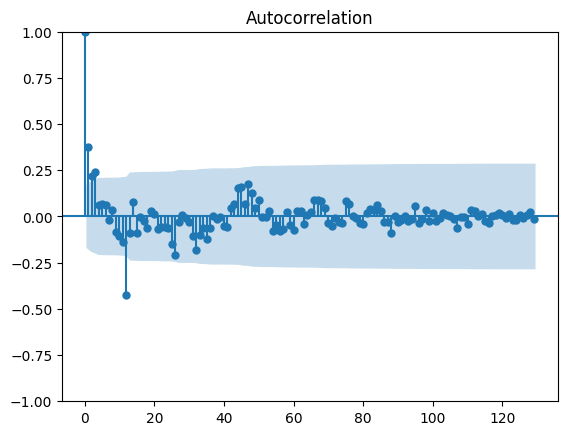

<Figure size 1000x400 with 0 Axes>

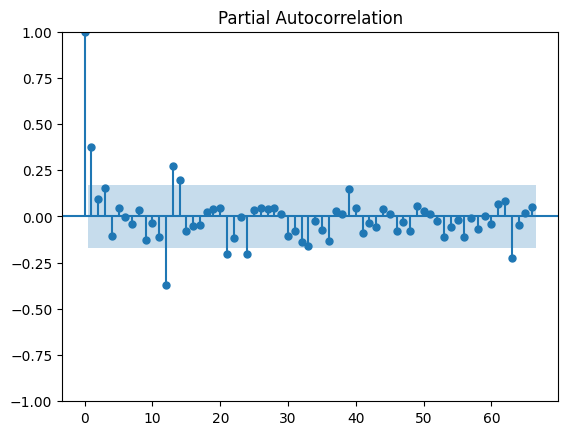

In [28]:
plot_acf(bright.diff(12).dropna(), lags=129)
plt.show()

plt.figure(figsize=(10, 4))
plot_pacf(bright.diff(12).dropna(), lags=66)
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


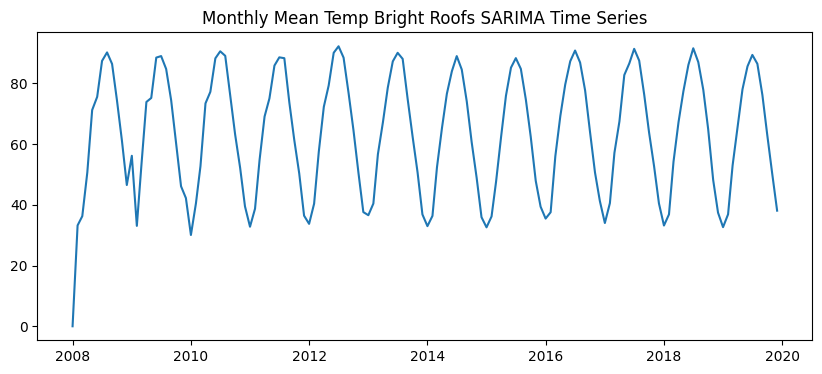

                                     SARIMAX Results                                      
Dep. Variable:                              Value   No. Observations:                  144
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -347.718
Date:                            Thu, 30 Apr 2026   AIC                            703.435
Time:                                    20:35:41   BIC                            714.936
Sample:                                01-01-2008   HQIC                           708.109
                                     - 12-01-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2880      0.115      2.506      0.012       0.063       0.513
ma.L1         -0.8906      0.065   

In [38]:

p, d, q = 1, 1, 1
P, D, Q, s = 0, 1, 1, 12

model5 = SARIMAX(bright, order=(p, d, q), seasonal_order=(P, D, Q, s))
model5_fit = model5.fit()
plt.figure(figsize=(10, 4))
plt.plot(model5_fit.fittedvalues)
plt.title("Monthly Mean Temp Bright Roofs SARIMA Time Series")
plt.show()

print(model5_fit.summary())

In [30]:
result = adfuller(dark, autolag='AIC')
print(f'ADF Statistic: {result[0]}')
print(f'n_lags: {result[2]}')
print(f'p-value: {result[1]}')
for key, value in result[4].items():
    print('Critial Values:')
    print(f'   {key}, {value}')

ADF Statistic: -2.806088641216118
n_lags: 12
p-value: 0.057409298626796244
Critial Values:
   1%, -3.4816817173418295
Critial Values:
   5%, -2.8840418343195267
Critial Values:
   10%, -2.578770059171598


In [31]:
seasonal_diffdark = dark.diff(12).dropna()
result = adfuller(seasonal_diffdark, autolag='AIC')
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

ADF Statistic: -4.489752899847906
p-value: 0.0002051955330596358


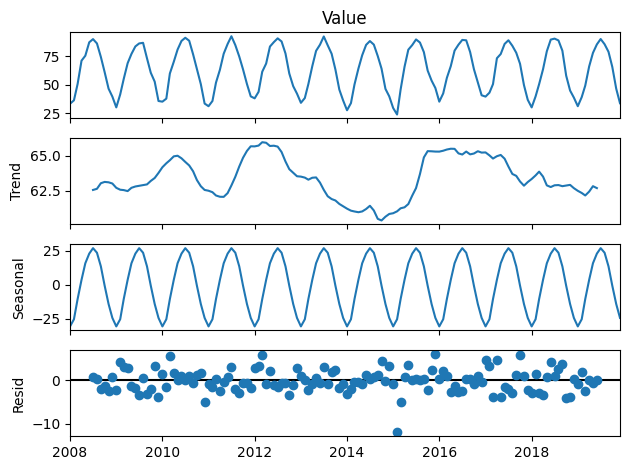

In [32]:
decomp = seasonal_decompose(bright, model='additive', period=12)

# Access components
trend = decomp.trend
seasonal = decomp.seasonal
residual = decomp.resid

# Visualize
decomp.plot()
plt.show()

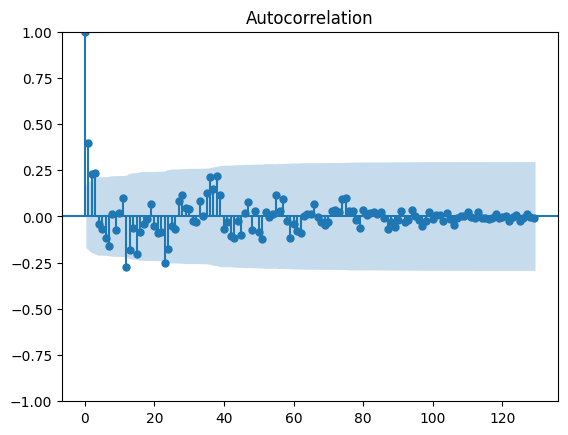

<Figure size 1000x400 with 0 Axes>

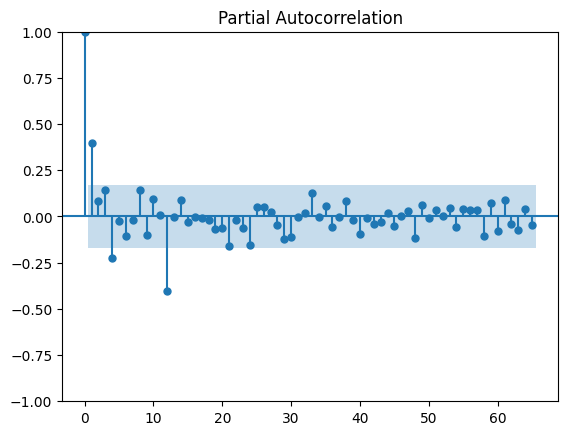

In [34]:
plot_acf(dark.diff(12).dropna(), lags=129)
plt.show()

plt.figure(figsize=(10, 4))
plot_pacf(dark.diff(12).dropna(), lags=65)
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


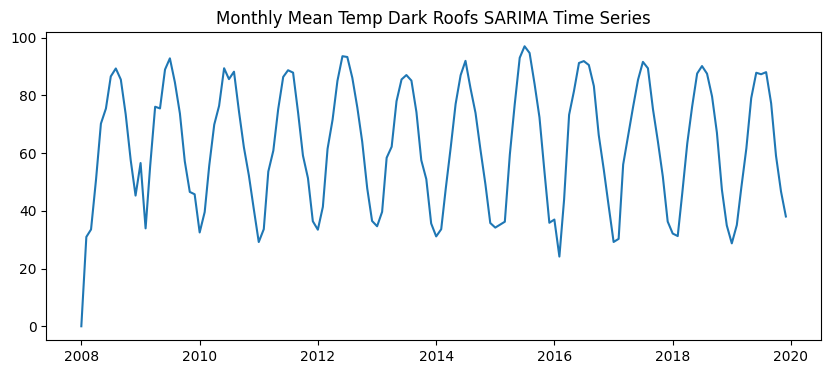

                                     SARIMAX Results                                      
Dep. Variable:                              Value   No. Observations:                  143
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -388.861
Date:                            Thu, 30 Apr 2026   AIC                            783.721
Time:                                    20:01:26   BIC                            792.324
Sample:                                         0   HQIC                           787.217
                                            - 143                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4119      0.074     -5.561      0.000      -0.557      -0.267
ma.S.L12      -0.4599      0.073   

In [36]:
p, d, q = 0, 1, 1
P, D, Q, s = 0, 1, 1, 12

model6 = SARIMAX(dark, order=(p, d, q), seasonal_order=(P, D, Q, s))
model6_fit = model6.fit()
plt.figure(figsize=(10, 4))
plt.plot(model6_fit.fittedvalues)
plt.title("Monthly Mean Temp Dark Roofs SARIMA Time Series")
plt.show()

print(model6_fit.summary())

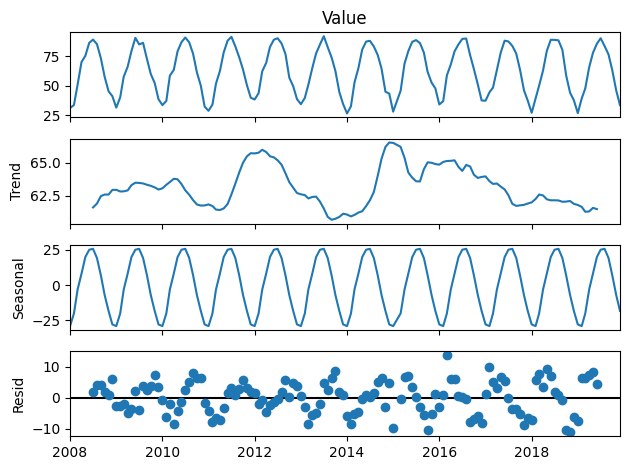

In [35]:
decomp = seasonal_decompose(dark, model='additive', period=12)

# Access components
trend = decomp.trend
seasonal = decomp.seasonal
residual = decomp.resid

# Visualize
decomp.plot()
plt.show()